#  News Topic Classifier — BERT Fine-Tuning
**Fine-tune `bert-base-uncased` on the AG News dataset**  

---
### Workflow
1. Install dependencies  
2. Load & explore AG News  
3. Tokenise the dataset  
4. Fine-tune BERT  
5. Save the model  


## 1 · Install Dependencies

In [1]:
!pip install transformers datasets accelerate scikit-learn seaborn gradio -q

## 2 · Imports & Configuration

In [2]:
import os, json, logging
import numpy as np
import torch
from pathlib import Path

from datasets import load_dataset
from transformers import (
    BertTokenizerFast,
    BertForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    DataCollatorWithPadding,
)
from sklearn.metrics import accuracy_score, f1_score

# ── Config ────────────────────────────────────────────────────
MODEL_NAME    = "bert-base-uncased"
OUTPUT_DIR    = "models/bert_ag_news"
MAX_LENGTH    = 128
BATCH_SIZE    = 32
EPOCHS        = 3
LEARNING_RATE = 2e-5
WEIGHT_DECAY  = 0.01
WARMUP_RATIO  = 0.1
SEED          = 42

LABEL_NAMES = {0: "World", 1: "Sports", 2: "Business", 3: "Sci/Tech"}

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
Path("outputs/logs").mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
print(f"PyTorch: {torch.__version__}")


Device : cpu
PyTorch: 2.12.0+cpu


## 3 · Load & Explore AG News Dataset

In [4]:
from datasets import load_dataset

ds = load_dataset("aRWA787/ag_news_dataset")
print("\nLabel names:", dataset["train"].features["label"].names)



Label names: ['World', 'Sports', 'Business', 'Sci/Tech']


In [5]:
import pandas as pd

# Show sample from each class
samples = []
for label_id, label_name in LABEL_NAMES.items():
    ex = [x for x in dataset["train"] if x["label"] == label_id][:2]
    for e in ex:
        samples.append({"Label": label_name, "Headline": e["text"][:100] + "…"})

pd.DataFrame(samples).style.set_properties(**{"text-align": "left"})


,Label,Headline
0,World,Venezuelans Vote Early in Referendum on Chavez Rule (Reuters) Reuters - Venezuelans turned out early…
1,World,S.Koreans Clash with Police on Iraq Troop Dispatch (Reuters) Reuters - South Korean police used wate…
2,Sports,"Phelps, Thorpe Advance in 200 Freestyle (AP) AP - Michael Phelps took care of qualifying for the Oly…"
3,Sports,"Reds Knock Padres Out of Wild-Card Lead (AP) AP - Wily Mo Pena homered twice and drove in four runs,…"
4,Business,"Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\b…"
5,Business,"Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Group,…"
6,Sci/Tech,"'Madden,' 'ESPN' Football Score in Different Ways (Reuters) Reuters - Was absenteeism a little high\…"
7,Sci/Tech,Group to Propose New High-Speed Wireless Format (Reuters) Reuters - A group of technology companies\…


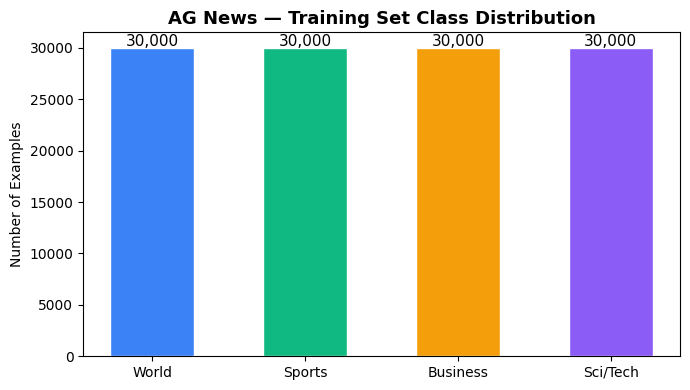

In [6]:
import matplotlib.pyplot as plt

# Class distribution
counts = [sum(1 for x in dataset["train"] if x["label"] == i) for i in range(4)]
colors = ["#3B82F6", "#10B981", "#F59E0B", "#8B5CF6"]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(list(LABEL_NAMES.values()), counts, color=colors, edgecolor="white", width=0.55)
ax.set_title("AG News — Training Set Class Distribution", fontsize=13, fontweight="bold")
ax.set_ylabel("Number of Examples")
for bar, c in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f"{c:,}", ha="center", fontsize=11)
plt.tight_layout()
plt.savefig("outputs/class_distribution.png", dpi=130)
plt.show()


## 4 · Tokenise the Dataset

In [7]:
tokenizer = BertTokenizerFast.from_pretrained(MODEL_NAME)

# Inspect tokenisation
sample_text = dataset["train"][0]["text"]
tokens = tokenizer(sample_text, truncation=True, max_length=MAX_LENGTH)
print("Sample text  :", sample_text[:80], "…")
print("Token count  :", len(tokens["input_ids"]))
print("First 10 toks:", tokenizer.convert_ids_to_tokens(tokens["input_ids"][:10]))


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

C:\Users\raozu\AppData\Local\miniconda3\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\raozu\.cache\huggingface\hub\models--bert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Sample text  : Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall  …
Token count  : 41
First 10 toks: ['[CLS]', 'wall', 'st', '.', 'bears', 'claw', 'back', 'into', 'the', 'black']


In [8]:
def tokenize_fn(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH,
        padding=False,          # dynamic padding via DataCollator
    )

tokenized = dataset.map(
    tokenize_fn,
    batched=True,
    remove_columns=["text"],
    desc="Tokenising",
)
tokenized = tokenized.rename_column("label", "labels")
tokenized.set_format("torch")
print("Tokenisation done.")
print(tokenized)


Tokenising:   0%|          | 0/120000 [00:00<?, ? examples/s]

Tokenising:   0%|          | 0/7600 [00:00<?, ? examples/s]

Tokenisation done.
DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 7600
    })
})


## 5 · Fine-Tune BERT

In [9]:
# Train / validation split
split   = tokenized["train"].train_test_split(test_size=0.05, seed=SEED)
train_ds = split["train"]
val_ds   = split["test"]
test_ds  = tokenized["test"]

print(f"Train  : {len(train_ds):,}")
print(f"Val    : {len(val_ds):,}")
print(f"Test   : {len(test_ds):,}")


Train  : 114,000
Val    : 6,000
Test   : 7,600


In [10]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy":    round(accuracy_score(labels, preds), 4),
        "f1_macro":    round(f1_score(labels, preds, average="macro"), 4),
        "f1_weighted": round(f1_score(labels, preds, average="weighted"), 4),
    }


In [11]:
model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=4,
    id2label=LABEL_NAMES,
    label2id={v: k for k, v in LABEL_NAMES.items()},
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    warmup_ratio=WARMUP_RATIO,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_dir="outputs/logs",
    logging_steps=100,
    report_to="none",
    seed=SEED,
    fp16=torch.cuda.is_available(),
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print("Starting training …")
trainer.train()


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_

TypeError: Trainer.__init__() got an unexpected keyword argument 'tokenizer'

## 6 · Save Model & Quick Test Eval

In [ ]:
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print(f"Model saved → {OUTPUT_DIR}/")

val_results = trainer.evaluate(val_ds)
print("\nValidation results:")
for k, v in val_results.items():
    print(f"  {k}: {v}")
